In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
from obspy import Inventory, UTCDateTime, read
from obspy.clients.fdsn import Client
dpath = '/Users/oxide/Documents/research/orenstein/code/P288FinalProject/alex/data/'

date = "2025-08-21"
starttime = UTCDateTime(f'{date}')
endtime = starttime+86400

date_range = ["2025-01-22", "2025-01-22"]

def parse_dates(date_string):
    # Try different format patterns
    formats = [
        "%Y-%m-%d %H:%M:%S.%f",       # Format 1
        "%Y-%m-%d_%H%M%S",            # Format 2
    ]
    
    for fmt in formats:
        try:
            return datetime.strptime(date_string, fmt)
        except ValueError:
            continue

def combine_and_interpolate(dataframes, target_index):
    interpolated_dfs = []
    
    for df in dataframes:
        # Remove duplicates by averaging (or use other methods like 'first', 'last')
        if df.index.duplicated().any():
            df = df.groupby(df.index).mean()
        # Reindex and interpolate
        reindexed = df.reindex(target_index)
        interpolated = reindexed.interpolate(method='linear')
        interpolated_dfs.append(interpolated)
    
    return pd.concat(interpolated_dfs, axis=1)

def combine_and_interpolate2(dataframes, target_index):
    """
    Uses numpy.interp which is index-value-based (like method='index' should be)
    """
    interpolated_dfs = []
    
    for df in dataframes:
        # Handle duplicates
        if df.index.duplicated().any():
            df = df.groupby(df.index).mean()
        
        # Create result dataframe
        result_df = pd.DataFrame(index=target_index, columns=df.columns, dtype=float)
        
        # Interpolate each column using numpy (index-value-based)
        for col in df.columns:
            if 'Datetime' not in col: # avoid interpolating date time
                valid_data = df[col].dropna()
                if len(valid_data) > 1:
                    result_df[col] = np.interp(target_index, valid_data.index, valid_data.values)
        
        interpolated_dfs.append(result_df)
    
    return pd.concat(interpolated_dfs, axis=1)

def combine_data():
    
    return 0 

In [5]:
seismic_data = pd.read_csv(dpath+'VPCC_RSAM_600s_local.csv', header=2, names=['Datetime Seismic', 'RSAM', 'Station', 'Channel'])

In [7]:
seismic_data

,Datetime Seismic,RSAM,Station,Channel
0,2024-01-31 18:10:00,138.005821,VPCC,HHZ
1,2024-01-31 18:20:00,139.288816,VPCC,HHZ
2,2024-01-31 18:30:00,127.812977,VPCC,HHZ
3,2024-01-31 18:40:00,168.776698,VPCC,HHZ
4,2024-01-31 18:50:00,130.234030,VPCC,HHZ
...,...,...,...,...
94321,2025-11-21 09:40:00,439.837284,VPCC,HHZ
94322,2025-11-21 09:50:00,437.636338,VPCC,HHZ
94323,2025-11-21 10:00:00,477.592038,VPCC,HHZ
94324,2025-11-21 10:10:00,443.619286,VPCC,HHZ


In [8]:
# load data seismic
#seismic_data = []
#for station in ['VPCC', 'VPRS']:
#    traceE = read(dpath+f'OV.{station}_HHE.m')[0]
#    traceN = read(dpath+f'OV.{station}_HHN.m')[0]
#    traceZ = read(dpath+f'OV.{station}_HHZ.m')[0]
#    timeseriesE = np.array(traceE)
#    timeseriesN = np.array(traceN)
#    timeseriesZ = np.array(traceZ)
#    timestamp = np.array([t.datetime for t in traceE.times(type='utcdatetime')])
#    dtime = f'Datetime {station} S'
#    column_names = [dtime, f'{station} Seismic E', f'{station} Seismic N', f'{station} Seismic Z']
#    df = pd.DataFrame(zip(timestamp, timeseriesE, timeseriesN, timeseriesZ), columns=column_names)
#    df['Timestamp'] = df[dtime].astype(np.int64)/1e9
#    df = df.set_index('Timestamp')
#    seismic_data.append(df)

# seismic data from Sarah
seismic_data = pd.read_csv(dpath+'VPCC_RSAM_600s_local.csv', header=2, names=['Datetime Seismic', 'RSAM', 'Station', 'Channel'])
seismic_data['Datetime Seismic'] = [parse_dates(dt) for dt in seismic_data['Datetime Seismic']]
seismic_data['Timestamp'] = seismic_data['Datetime Seismic'].astype(np.int64)/1e9
seismic_data = seismic_data.set_index('Timestamp')

# load magnetic data
magnetic_data = []
for station in ['VPRS']:
    traceE = read(dpath+f'OV.{station}_LFE.m')[0]
    traceN = read(dpath+f'OV.{station}_LFN.m')[0]
    traceZ = read(dpath+f'OV.{station}_LFZ.m')[0]
    timeseriesE = np.array(traceE)
    timeseriesN = np.array(traceN)
    timeseriesZ = np.array(traceZ)
    timestamp = np.array([t.datetime for t in traceE.times(type='utcdatetime')])
    dtime = f'Datetime {station} M'
    column_names = [dtime, f'{station} Field E', f'{station} Field N', f'{station} Field Z']
    df = pd.DataFrame(zip(timestamp, timeseriesE, timeseriesN, timeseriesZ), columns=column_names)
    df['Timestamp'] = df[dtime].astype(np.int64)/1e9
    df = df.set_index('Timestamp')
    magnetic_data.append(df)


# load soil CO2 data
soilCO2 = pd.read_csv(dpath+'CO2.csv', header=2, names=['Datetime CO2', 'CO2 concentration', 'Year'])
soilCO2['Datetime CO2'] = [parse_dates(dt) for dt in soilCO2['Datetime CO2']]
soilCO2['Timestamp'] = soilCO2['Datetime CO2'].astype(np.int64)/1e9
soilCO2 = soilCO2.set_index('Timestamp')

# load weather
df1 = pd.read_csv(dpath+'VPMI_weather_2024.csv', delimiter=',', header=0)
df2 = pd.read_csv(dpath+'VPMI_weather_2025.csv', delimiter=',', header=0)
weather = pd.concat([df1, df2])
weather['Datetime'] = [parse_dates(dt) for dt in weather['Datetime']]
weather['Timestamp'] = weather['Datetime'].astype(np.int64)/1e9
weather = weather.set_index('Timestamp')

TypeError: int() argument must be a string, a bytes-like object or a real number, not 'NoneType'

In [4]:
# combine and interpolate
target_times = magnetic_data[0].index
dataframes = [seismic_data[0], seismic_data[1], magnetic_data[0], soilCO2, weather]
dataframes = [seismic_data[0], seismic_data[1], magnetic_data[0], soilCO2]
combined = combine_and_interpolate2(dataframes, target_times)

NameError: name 'seismic_data' is not defined

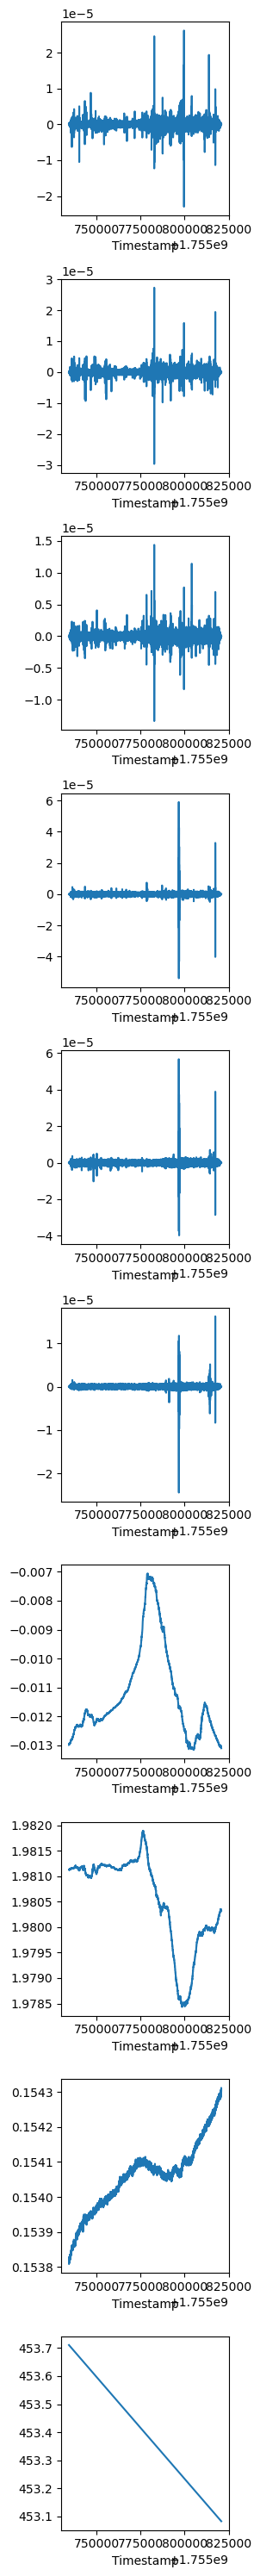

In [98]:
vars = []
for station in ['VPCC', 'VPRS']:
    for channel in ['E', 'N', 'Z']:
        vars.append(combined[f'{station} Seismic {channel}'])
for station in ['VPRS']:
    for channel in ['E', 'N', 'Z']:
        vars.append(combined[f'{station} Field {channel}'])
vars.append(combined['CO2 concentration'])

scale=3
fig, ax = plt.subplots(len(vars), figsize=(scale, scale*len(vars)))

for ii, v in enumerate(vars):
    v.plot(ax=ax[ii])

fig.tight_layout()